In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
df = pd.read_csv("heloc_dataset_v1.csv")

# Task 1: Formulating the Problem
**Prediction Task:** 
- Binary Classification: Predict RiskPerformance (Good/Bad); Bad = loan defaulted, Good = loan paid back on time
- Decision rule: If predicted "Good" → send to loan officer; If predicted "Bad" → auto-deny

**Appropriate Measures of Performance:**
- Look at Homework Part 2
- Recall (Sensitivity) for "Good" class - minimize missing good applicants
- Precision for "Bad" class - ensure denials are justified
- Accuracy for overall correctness
- F1-score for overall balance and measurement for the model

**Sufficient Performance Level:** (we can aim for this first, and if it doesn't work out we can adjust the values...)
- Minimum: 70-75% recall on "Good" class (catch most good applicants)
- Target: 80%+ AUC-ROC for production deployment

**Cost Savings:**
- ig we make assumptions for this like: 

--> Manual review: $50/application

--> 10,000 applications/year
- we should ask the professor

# Task 2: Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("heloc_dataset_v1.csv")

# Basic inspection
print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

# Target distribution
display(df["RiskPerformance"].value_counts())
display((df["RiskPerformance"].value_counts(normalize=True) * 100).round(2))


Shape: (10459, 24)


,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


RiskPerformance                         str
ExternalRiskEstimate                  int64
MSinceOldestTradeOpen                 int64
MSinceMostRecentTradeOpen             int64
AverageMInFile                        int64
NumSatisfactoryTrades                 int64
NumTrades60Ever2DerogPubRec           int64
NumTrades90Ever2DerogPubRec           int64
PercentTradesNeverDelq                int64
MSinceMostRecentDelq                  int64
MaxDelq2PublicRecLast12M              int64
MaxDelqEver                           int64
NumTotalTrades                        int64
NumTradesOpeninLast12M                int64
PercentInstallTrades                  int64
MSinceMostRecentInqexcl7days          int64
NumInqLast6M                          int64
NumInqLast6Mexcl7days                 int64
NetFractionRevolvingBurden            int64
NetFractionInstallBurden              int64
NumRevolvingTradesWBalance            int64
NumInstallTradesWBalance              int64
NumBank2NatlTradesWHighUtilizati

RiskPerformance
Bad     5459
Good    5000
Name: count, dtype: int64

RiskPerformance
Bad     52.19
Good    47.81
Name: proportion, dtype: float64

## Step 1: Initial Data Inspection

We begin by loading the HELOC dataset and conducting basic validation checks.

Key outputs reviewed:
1. Dataset size and structure (number of rows and columns)
2. First few rows to validate formatting and confirm expected fields
3. Data types for each feature to understand preprocessing needs
4. Target distribution for `RiskPerformance` (Good vs Bad)

This confirms that the target variable is categorical and that predictors are primarily numeric. We also document whether the target classes are reasonably balanced, since class imbalance can affect evaluation metrics and modeling choices.


In [4]:
# Identify numeric predictor columns (exclude target)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols.remove("RiskPerformance") if "RiskPerformance" in numeric_cols else None

# -9 No Bureau Record or No Investigation
# -8 No Usable/Valid Trades or Inquiries
sentinels = [-9, -8]

# Detect rows where all numeric values are sentinel-coded
all_sentinel_mask = df[numeric_cols].apply(lambda row: row.isin(sentinels).all(), axis=1)

print("Rows with all sentinel-coded values:", all_sentinel_mask.sum())

# Remove completely invalid rows
df_step2 = df.loc[~all_sentinel_mask].copy()

print("Original rows:", df.shape[0])
print("Remaining rows after removing invalid rows:", df_step2.shape[0])


Rows with all sentinel-coded values: 588
Original rows: 10459
Remaining rows after removing invalid rows: 9871


## Step 2: Removal of Completely Invalid Rows

The dataset uses sentinel codes (-9, -8) to represent missing or unusable values.

Before converting these to NaN, we identify rows where **all numeric predictor values are sentinel-coded**. These rows contain no usable credit information and therefore provide no modeling value.

Such rows are removed to prevent distortion in downstream analysis.

This step mirrors the cleaning approach used in Homework Part 1, where completely unusable observations were dropped prior to detailed EDA.

Importantly, we do not remove rows with partial missingness at this stage.


In [5]:
# Create working copy
df_step3 = df_step2.copy()

# Replace sentinel codes with NaN
# df_step3[numeric_cols] = df_step3[numeric_cols].replace(sentinels, np.nan)
df_step3[numeric_cols] = df_step3[numeric_cols].mask(df_step3[numeric_cols].isin(sentinels))

# Verify replacement
print("Remaining sentinel values:",
      (df_step3[numeric_cols].isin(sentinels)).sum().sum())


Remaining sentinel values: 0


See which columns have the value -7 (-7 Condition not Met (e.g. No Inquiries, No Delinquencies)). This needs to be handled separately later on because they can be informing instead of misleading the model's learning.

In [6]:
cols_with_neg7 = df_step3.columns[(df_step3 == -7).any()]
print(cols_with_neg7.tolist())

# Make a copy of the dataframe for later cleaning
df_clean = df_step2.copy()

'''
To-do:
- impute -9 and -8 with median 
- investigate how to interpret -7 for ['MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days']
'''

['MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days']


"\nTo-do:\n- impute -9 and -8 with median \n- investigate how to interpret -7 for ['MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days']\n"

## Step 3: Convert Sentinel Codes to Proper Missing Values

After removing completely invalid rows, the remaining sentinel codes (-9, -8) are converted to NaN.

This ensures that:

- Missingness is correctly recognized by pandas.
- Summary statistics are not distorted.
- Correlation calculations are valid.
- Imputation methods can be applied later in a consistent way.

At this stage, no rows are dropped due to partial missingness. We first quantify and analyze the missing structure before making further decisions.


In [7]:
# Column-wise missing percentage
col_missing_pct = (df_step3[numeric_cols].isna().mean() * 100).round(2)
col_missing_pct = col_missing_pct.sort_values(ascending=False)

print("Top columns by missing percentage:")
display(col_missing_pct.head(15))

# Row-wise missing percentage|
row_missing_pct = (df_step3[numeric_cols].isna().mean(axis=1) * 100)

print("Row-wise missing summary:")
display(row_missing_pct.describe())


Top columns by missing percentage:


NetFractionInstallBurden              34.64
NumInstallTradesWBalance               8.72
NumBank2NatlTradesWHighUtilization     5.91
MSinceMostRecentInqexcl7days           4.82
MSinceOldestTradeOpen                  2.42
NetFractionRevolvingBurden             1.88
MSinceMostRecentDelq                   1.78
NumRevolvingTradesWBalance             1.58
PercentTradesWBalance                  0.18
ExternalRiskEstimate                   0.10
MaxDelqEver                            0.00
MaxDelq2PublicRecLast12M               0.00
NumTradesOpeninLast12M                 0.00
PercentInstallTrades                   0.00
PercentTradesNeverDelq                 0.00
dtype: float64

Row-wise missing summary:


count    9871.000000
mean        2.697405
std         3.812377
min         0.000000
25%         0.000000
50%         0.000000
75%         4.347826
max        30.434783
dtype: float64

## Step 4: Missingness Analysis

After converting sentinel values to NaN, we quantify missingness at both the column and row level.

Column-wise missingness helps identify:
- Features with high structural absence
- Variables that may require special handling or removal

Row-wise missingness helps determine:
- Whether a subset of observations is excessively incomplete
- Whether row deletion thresholds should be considered

We do not immediately drop rows or features. Instead, we first document the missing structure and then determine appropriate mitigation strategies.


In [8]:
# Categorize missingness levels
high_missing = col_missing_pct[col_missing_pct > 40]
moderate_missing = col_missing_pct[(col_missing_pct > 10) & (col_missing_pct <= 40)]
low_missing = col_missing_pct[col_missing_pct <= 10]

print("High missing (>40%):")
display(high_missing)

print("Moderate missing (10–40%):")
display(moderate_missing.head(10))

print("Low missing (<=10%):")
display(low_missing.head(10))


High missing (>40%):


Series([], dtype: float64)

Moderate missing (10–40%):


NetFractionInstallBurden    34.64
dtype: float64

Low missing (<=10%):


NumInstallTradesWBalance              8.72
NumBank2NatlTradesWHighUtilization    5.91
MSinceMostRecentInqexcl7days          4.82
MSinceOldestTradeOpen                 2.42
NetFractionRevolvingBurden            1.88
MSinceMostRecentDelq                  1.78
NumRevolvingTradesWBalance            1.58
PercentTradesWBalance                 0.18
ExternalRiskEstimate                  0.10
MaxDelqEver                           0.00
dtype: float64

## Step 5: Missingness Classification

We classify features into three categories based on missingness:

High missing (>40%)
These variables contain substantial structural absence and may require:
- Special treatment
- Missing indicators
- Careful imputation
- Or potential removal depending on modeling needs

Moderate missing (10–40%)
These variables likely contain informative missingness and should:
- Be retained
- Use imputation
- Possibly include missing flags

Low missing (<=10%)
These variables are stable and can be handled with standard imputation.

This structured classification ensures we are not making arbitrary deletion decisions.


In [9]:
# Add binary target 
df_step3["RiskPerformance_binary"] = df_step3["RiskPerformance"].map({"Bad": 1, "Good": 0})

# Compare missingness by target
missing_by_target = (
    df_step3
    .groupby("RiskPerformance_binary")[numeric_cols]
    .apply(lambda x: x.isna().mean() * 100)
)

display(missing_by_target.T.head(15))


RiskPerformance_binary,0,1
ExternalRiskEstimate,0.042239,0.155763
MSinceOldestTradeOpen,2.323126,2.511682
MSinceMostRecentTradeOpen,0.000000,0.000000
AverageMInFile,0.000000,0.000000
NumSatisfactoryTrades,0.000000,0.000000
NumTrades60Ever2DerogPubRec,0.000000,0.000000
NumTrades90Ever2DerogPubRec,0.000000,0.000000
PercentTradesNeverDelq,0.000000,0.000000
MSinceMostRecentDelq,1.520591,2.024922
MaxDelq2PublicRecLast12M,0.000000,0.000000


## Step 6: Is Missingness Predictive?

We compare feature-level missingness across Good and Bad classes.

If missingness differs meaningfully between classes, then missing values are not random and should not be blindly removed.

In credit datasets, structural absence (e.g., no delinquency history) often carries predictive signal.

This step ensures that our handling of missing values does not discard informative structure.


In [10]:
# Step 6: Multicollinearity Check

# Compute full correlation matrix across numeric predictors
corr_matrix = df_step3[numeric_cols].corr()

# Extract upper triangle to avoid duplicate pairs
corr_pairs = (
    corr_matrix
        .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
)

# Display top correlated pairs
corr_pairs.head(15)


NumInqLast6M                 NumInqLast6Mexcl7days                 0.992205
NumTrades60Ever2DerogPubRec  NumTrades90Ever2DerogPubRec           0.890473
NumSatisfactoryTrades        NumTotalTrades                        0.845826
MSinceOldestTradeOpen        AverageMInFile                        0.692108
PercentTradesNeverDelq       MaxDelqEver                           0.638967
NumRevolvingTradesWBalance   NumBank2NatlTradesWHighUtilization    0.627779
ExternalRiskEstimate         NetFractionRevolvingBurden           -0.626352
MaxDelq2PublicRecLast12M     MaxDelqEver                           0.610689
NetFractionRevolvingBurden   PercentTradesWBalance                 0.606583
                             NumBank2NatlTradesWHighUtilization    0.605162
NumTrades60Ever2DerogPubRec  MaxDelqEver                          -0.587513
ExternalRiskEstimate         MaxDelq2PublicRecLast12M              0.568420
MSinceMostRecentDelq         MaxDelqEver                          -0.565237
NumTrades60E

In [11]:
# Flag highly correlated variable pairs
high_corr = corr_pairs[abs(corr_pairs) > 0.8]

high_corr


NumInqLast6M                 NumInqLast6Mexcl7days          0.992205
NumTrades60Ever2DerogPubRec  NumTrades90Ever2DerogPubRec    0.890473
NumSatisfactoryTrades        NumTotalTrades                 0.845826
dtype: float64

In [12]:
# Drop highly collinear redundant variables

cols_to_drop = [
    "NumInqLast6Mexcl7days",
    "NumTrades90Ever2DerogPubRec",
    "NumTotalTrades"
]

df_step4 = df_step3.drop(columns=cols_to_drop)

df_step4.shape


(9871, 22)

## Multicollinearity Resolution

Three highly correlated feature clusters were identified:

NumInqLast6M and NumInqLast6Mexcl7days

NumTrades60Ever2DerogPubRec and NumTrades90Ever2DerogPubRec

NumSatisfactoryTrades and NumTotalTrades

To reduce redundancy and stabilize model estimation, one variable from each correlated pair was removed.

This ensures:

Reduced variance inflation

Improved coefficient stability

Better generalization in linear models

Cleaner feature space before predictive modeling

The resulting dataset (df_step4) will be used for model development.

In [13]:
# Fix: realign numeric_cols to what actually exists in df_step4
numeric_cols_step4 = [c for c in numeric_cols if c in df_step4.columns]

# Optional sanity check (prints what was missing)
missing_from_df = [c for c in numeric_cols if c not in df_step4.columns]
print("Missing columns removed from numeric_cols:", missing_from_df)

# Now recompute correlation with target
corr_with_target_clean = (
    df_step4[numeric_cols_step4]
    .corrwith(df_step4["RiskPerformance_binary"])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_with_target_clean.head(15)


Missing columns removed from numeric_cols: ['NumTrades90Ever2DerogPubRec', 'NumTotalTrades', 'NumInqLast6Mexcl7days']


ExternalRiskEstimate                 -0.460381
NetFractionRevolvingBurden            0.355754
PercentTradesWBalance                 0.279369
PercentTradesNeverDelq               -0.257358
NumBank2NatlTradesWHighUtilization    0.245632
AverageMInFile                       -0.243869
MaxDelq2PublicRecLast12M             -0.236759
MaxDelqEver                          -0.216764
MSinceOldestTradeOpen                -0.216058
MSinceMostRecentInqexcl7days         -0.179284
NumTrades60Ever2DerogPubRec           0.169747
NumInqLast6M                          0.143640
NumSatisfactoryTrades                -0.141092
PercentInstallTrades                  0.140418
NumRevolvingTradesWBalance            0.131538
dtype: float64

## Step 7: Correlation with Target After Multicollinearity Removal

After removing highly collinear predictors, we recomputed the correlation between the remaining numeric features and the target variable RiskPerformance_binary.

We rank features by absolute correlation to identify the strongest linear predictors.

Strongest Predictors

ExternalRiskEstimate: −0.460
Strongest linear relationship. Higher external risk score is associated with lower probability of bad performance.

NetFractionRevolvingBurden: 0.356
Higher revolving utilization burden is associated with higher probability of bad performance.

PercentTradesWBalance: 0.279
More trades carrying balances increase risk.

PercentTradesNeverDelq: −0.257
Higher percentage of never-delinquent trades reduces risk.

NumBank2NatlTradesWHighUtilization: 0.246
High utilization across accounts increases risk.

AverageMInFile: −0.244
Longer credit history reduces risk.

Moderate Predictors

MaxDelq2PublicRecLast12M: −0.237

MaxDelqEver: −0.217

MSinceOldestTradeOpen: −0.216

MSinceMostRecentInqexcl7days: −0.193

MSinceMostRecentDelq: −0.190

Weaker Predictors

NumTrades60Ever2DerogPubRec: 0.170

NumInqLast6M: 0.144

NumSatisfactoryTrades: −0.141

PercentInstallTrades: 0.140

Interpretation

Risk score, revolving burden, and delinquency-related variables show the strongest signal.

Signs are economically intuitive.

No single feature dominates completely, suggesting a multivariate model will be necessary.

/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


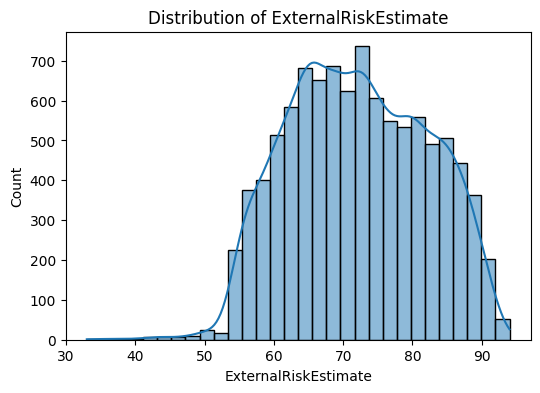

/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


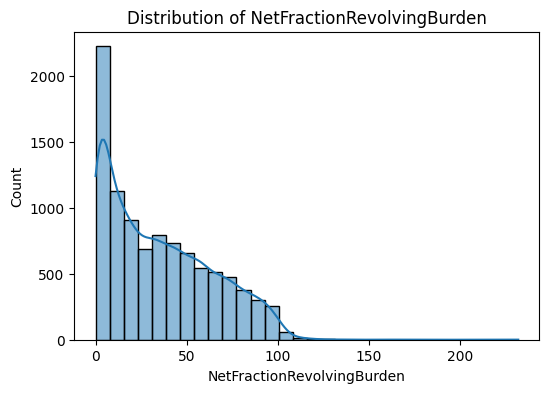

/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


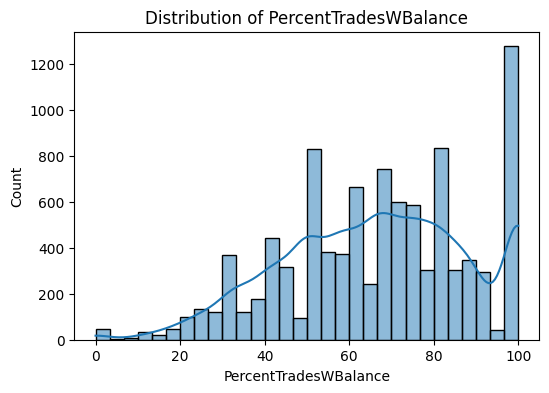

/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


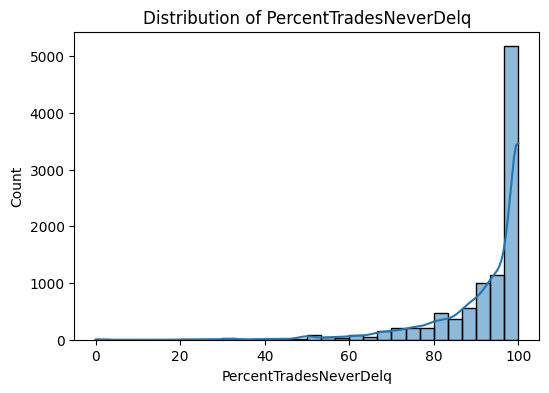

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions for top predictors
top_features = [
    "ExternalRiskEstimate",
    "NetFractionRevolvingBurden",
    "PercentTradesWBalance",
    "PercentTradesNeverDelq"
]

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df_step3[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


## Step 8: Top Predictors Feature Distribution

We examine the distributional shape of key numeric predictors to identify skewness, heavy tails, and potential outliers that may affect model performance.

1. ExternalRiskEstimate

The distribution appears approximately bell shaped with moderate spread. There is no extreme skewness or heavy tail behavior.
This variable does not require aggressive transformation.

2. NetFractionRevolvingBurden

This variable is strongly right skewed with a long upper tail extending beyond 200.
A small number of observations have very high revolving burden, which may influence linear models.
Log transformation or robust scaling should be considered during preprocessing.

3. PercentTradesWBalance

The distribution is moderately spread across the 0 to 100 range with some clustering toward higher values.
No severe skewness is observed, though mild non normality exists.
Standard scaling should be sufficient.

4. PercentTradesNeverDelq

This variable is heavily concentrated near 100 with a left tail.
The strong ceiling effect suggests many customers have near perfect repayment history.
While not problematic, this non normal shape should be handled carefully in linear models.

In [15]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = len(outliers)

    return pd.Series(outlier_summary).sort_values(ascending=False)

outlier_counts = detect_outliers_iqr(df_step3, numeric_cols)
outlier_counts.head(10)


MSinceMostRecentInqexcl7days    3821
NumTrades90Ever2DerogPubRec     2232
MaxDelqEver                      739
PercentTradesNeverDelq           695
MSinceMostRecentTradeOpen        646
MSinceMostRecentDelq             646
NumTrades60Ever2DerogPubRec      575
NumRevolvingTradesWBalance       550
NumInqLast6M                     399
MaxDelq2PublicRecLast12M         390
dtype: int64

## Interpretation

Several credit history and delinquency related variables contain a substantial number of extreme values.

Many of these variables are count based and naturally right skewed, so high values may represent genuine high risk behavior rather than data errors.

Immediate row removal is not recommended at the EDA stage.

Robust scaling or transformation should be considered during preprocessing instead of deletion.


FEATURE DISTRIBUTIONS


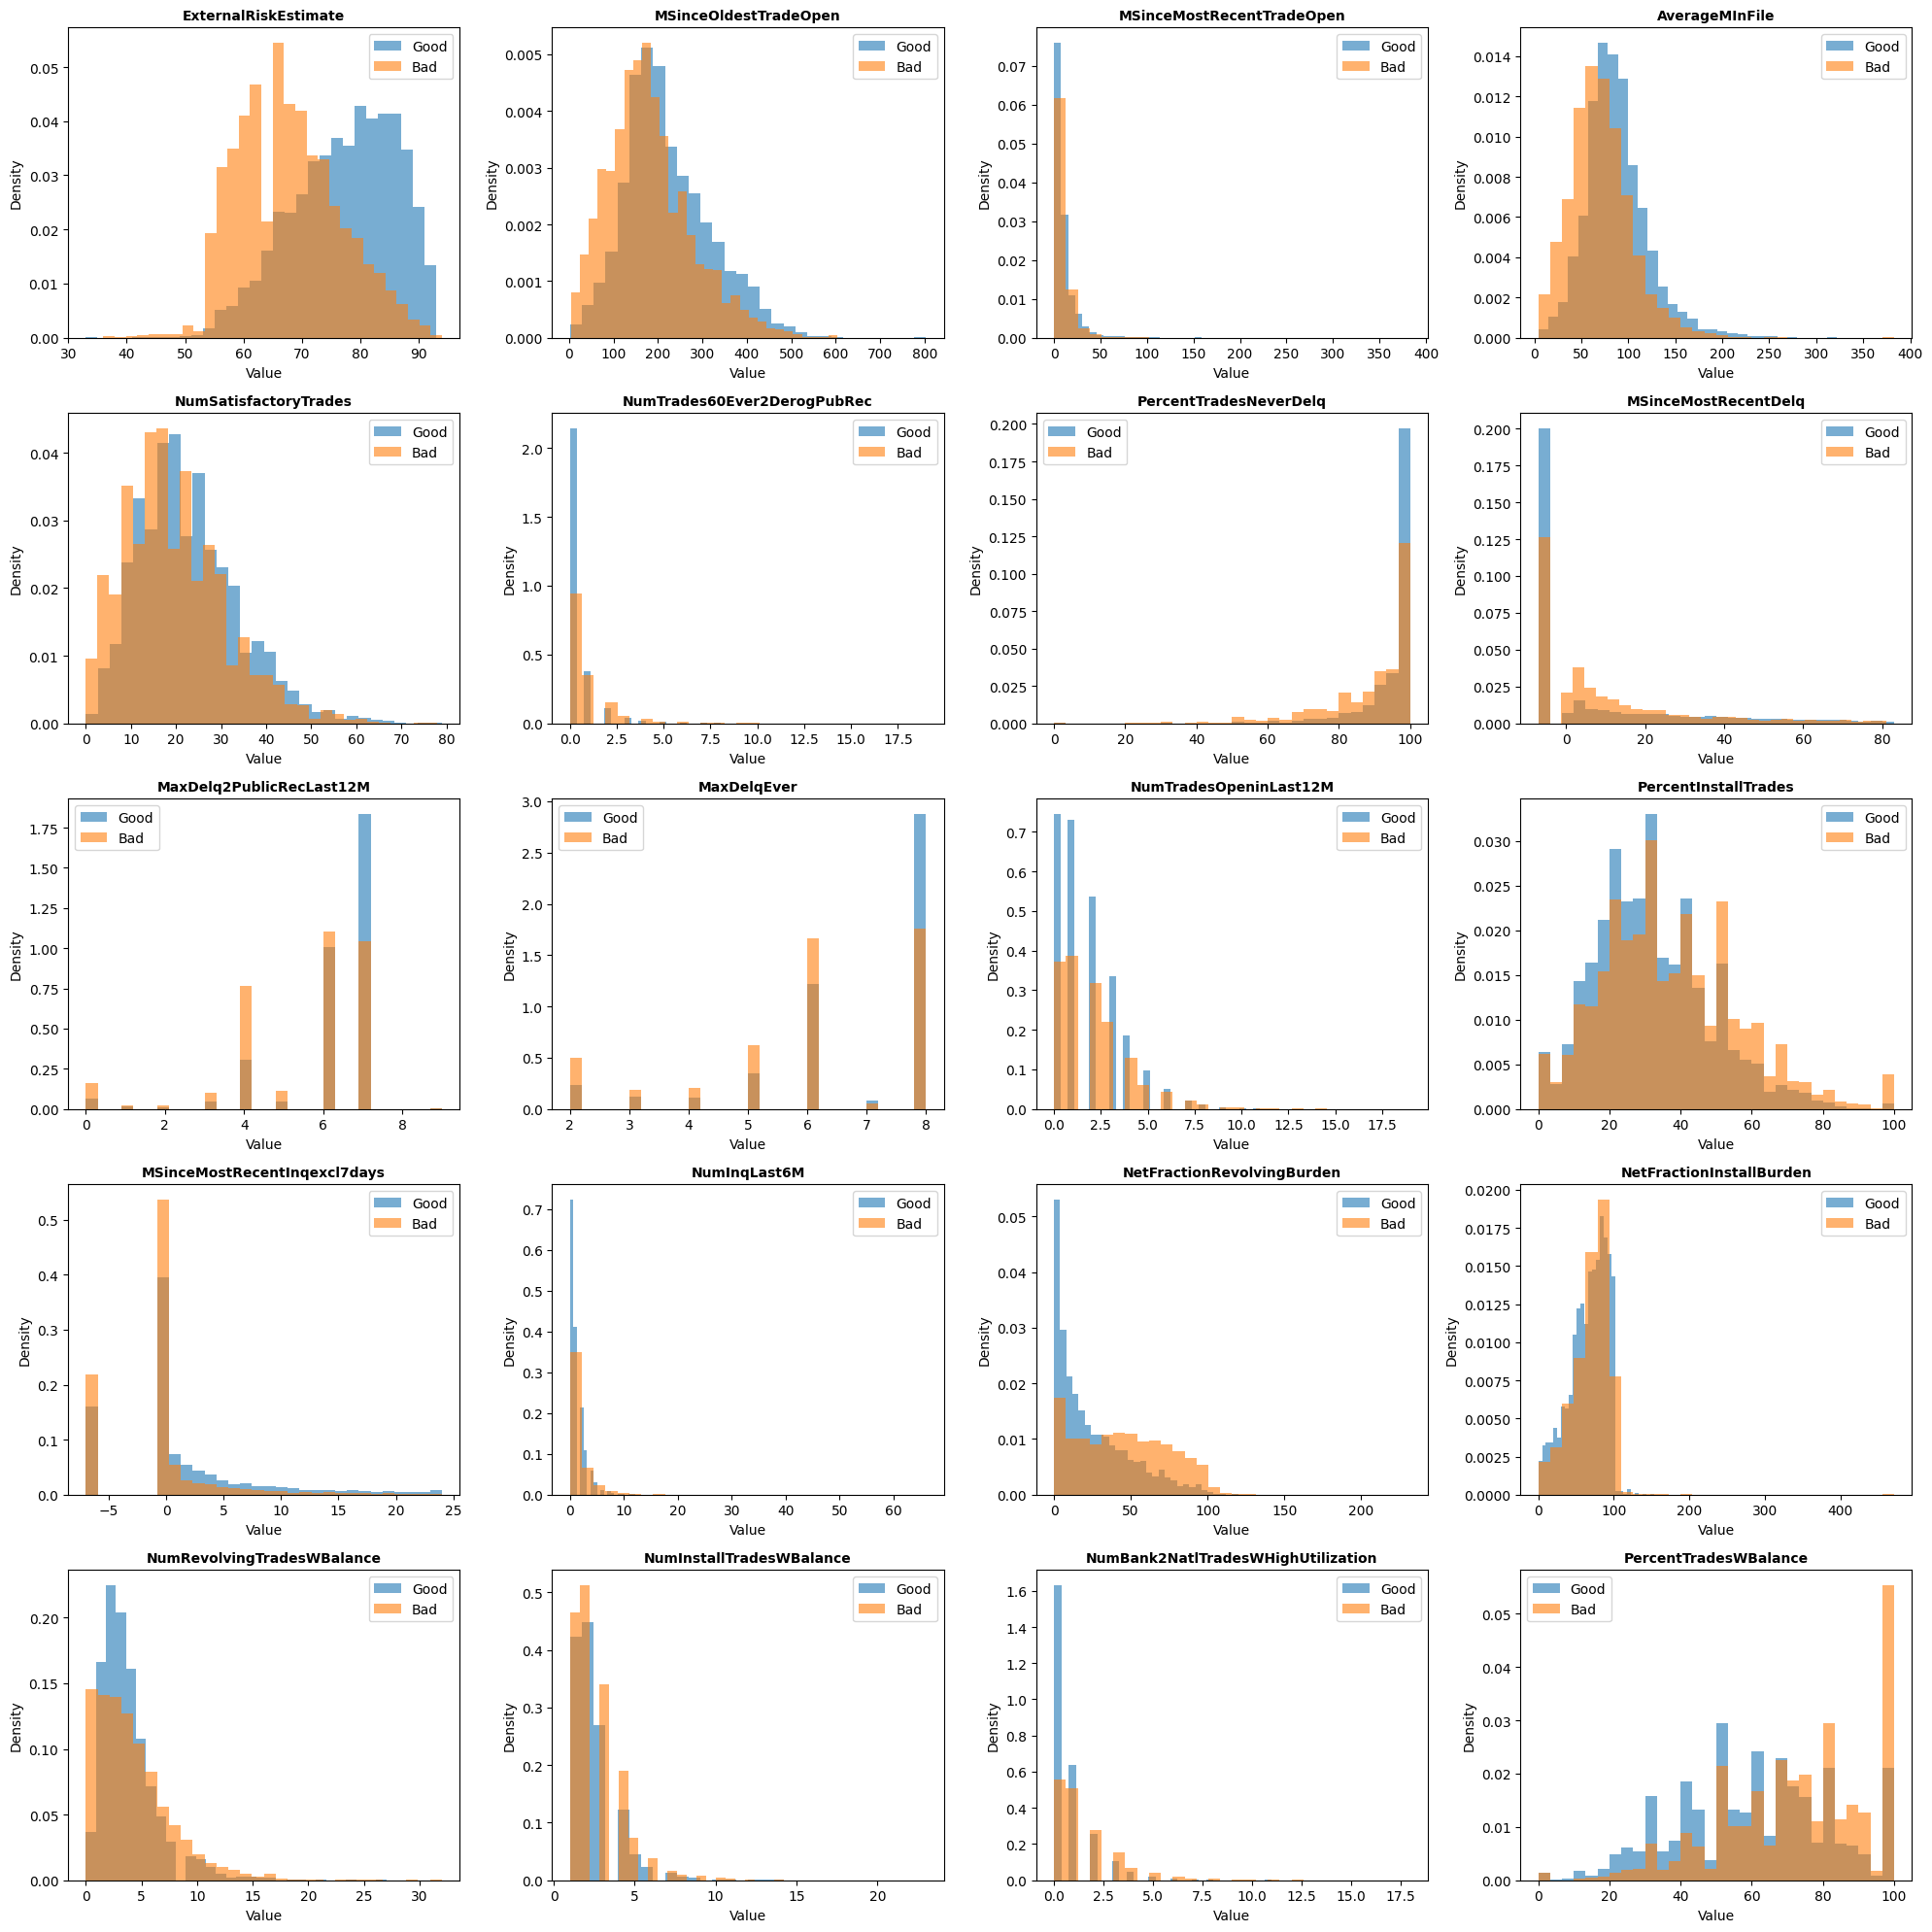


MEAN VALUES BY CLASS
RiskPerformance                            Bad        Good
ExternalRiskEstimate                 67.694423   76.790830
MSinceOldestTradeOpen               180.431396  222.786595
MSinceMostRecentTradeOpen             9.011682   10.214150
AverageMInFile                       70.801791   87.429989
NumSatisfactoryTrades                19.587812   22.785005
NumTrades60Ever2DerogPubRec           0.783294    0.362408
NumTrades90Ever2DerogPubRec           0.518692    0.239493
PercentTradesNeverDelq               89.450935   95.515312
MSinceMostRecentDelq                  9.293919    6.575381
MaxDelq2PublicRecLast12M              5.384151    6.163464
MaxDelqEver                           5.989681    6.791975
NumTotalTrades                       21.377531   24.000000
NumTradesOpeninLast12M                1.999805    1.716367
PercentInstallTrades                 37.039136   31.993242
MSinceMostRecentInqexcl7days         -0.339466    1.708065
NumInqLast6M                      

In [16]:
print("\n" + "=" * 60)
print("FEATURE DISTRIBUTIONS")
print("=" * 60)

df_viz = df_step4.copy()

# If you still have raw sentinel codes present anywhere, list them here
# missing_codes = [-9, -8, -7]
missing_codes = [-9, -8]

# Convert sentinel codes to NaN for visualization only
numeric_cols_viz = df_viz.select_dtypes(include=["number"]).columns.tolist()
for col in numeric_cols_viz:
    df_viz.loc[df_viz[col].isin(missing_codes), col] = np.nan

# Identify numeric feature columns (exclude target-like columns)
exclude_cols = {"RiskFlag", "RiskPerformance_binary"}
numeric_features = [c for c in numeric_cols_viz if c not in exclude_cols]

# Optionally remove very high-missing columns from plotting
missing_rate = df_viz[numeric_features].isnull().mean()
plot_features = [c for c in numeric_features if missing_rate[c] <= 0.50]

# Also exclude RiskPerformance if it is numeric (usually it is object, so safe)
plot_features = [c for c in plot_features if c != "RiskPerformance"]

# Plot overlaid distributions by class
n_features = len(plot_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(plot_features):
    good_data = df_viz.loc[df_viz["RiskPerformance"] == "Good", col].dropna()
    bad_data = df_viz.loc[df_viz["RiskPerformance"] == "Bad", col].dropna()

    axes[idx].hist(good_data, bins=30, alpha=0.6, density=True, label="Good")
    axes[idx].hist(bad_data, bins=30, alpha=0.6, density=True, label="Bad")
    axes[idx].set_title(col, fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Density")
    axes[idx].legend()

# Hide any unused axes
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("MEAN VALUES BY CLASS")
print("=" * 60)

# Mean comparison table (exclude any non numeric columns automatically)
numeric_features_for_means = df_step3.select_dtypes(include=["number"]).columns.tolist()
numeric_features_for_means = [c for c in numeric_features_for_means if c not in exclude_cols]

summary_stats = df_step3.groupby("RiskPerformance")[numeric_features_for_means].mean()
print(summary_stats.T)

**The Table (Mean Values):**

Compare Bad vs Good columns - bigger differences = more predictive:

- Strong differences:

1. ExternalRiskEstimate: 67.6 (Bad) vs 76.8 (Good) → 9-point gap 
2. PercentTradesNeverDelq: 89.5 (Bad) vs 95.5 (Good) → 6-point gap 
3. NetFractionRevolvingBurden: 43.3 (Bad) vs 24.0 (Good) → 19-point gap! 

- Small differences:

1. NumTradesOpeninLast12M: 2.0 (Bad) vs 1.7 (Good) → Only 0.3 difference, weak

## EDA Summary

1. **Missing Value Analysis**
   - No actual NaN values in dataset
   - Missing values encoded as special codes: -9, -8
   - MSinceMostRecentDelq: 52% missing
   - NetFractionInstallBurden: 38% missing
   - **Removed 588 rows where ALL numeric columns were missing codes** (-9, -8) --> HW only removed -9 rows, but still total of 588 removed.
   - Retained 9,871 rows (94.4%) with partial missing values
   - Partial missing values kept for later imputation

2. **Class Balance Check**
   - Bad: 52% (5,136 loans)
   - Good: 48% (4,735 loans)
   - Fairly balanced - no severe imbalance issue

3. **Correlation Analysis**
   - **Strongest predictors** (correlation with target):
     - ExternalRiskEstimate: -0.45 (lower score = higher risk)
     - NetFractionRevolvingBurden: +0.33 (higher burden = higher risk)
     - PercentTradesWBalance: +0.27
     - Multicollinearity addressed
  

4. **Outlier Detection**
   - Found extreme values in MSinceOldestTradeOpen (800+ months), NetFractionRevolvingBurden
   - Can keep outliers (may represent legitimate long credit histories)

5. **Feature Distribution Analysis**
   - Calculated summary statistics for all 23 numeric features
   - Visualized distributions for 22 features (excluded MSinceMostRecentDelq due to >50% missing)
   - Compared Good vs Bad for each feature
   
   **Strong predictors (large mean differences & clear visual separation):**
   - **ExternalRiskEstimate**: Bad=67.6 vs Good=76.8 (Δ=9.2) - Lower score = higher risk
   - **MSinceOldestTradeOpen**: Bad=175.7 vs Good=217.4 (Δ=41.7 months) - Shorter history = higher risk
   - **NetFractionRevolvingBurden**: Bad=43.3 vs Good=24.0 (Δ=19.3) - Higher burden = higher risk
   - **PercentTradesNeverDelq**: Bad=89.5 vs Good=95.5 (Δ=6.0) - More late payments = higher risk
   - **NumTrades60/90Ever2DerogPubRec**: Bad has ~2x more derogatory marks than Good
   
   **Moderate predictors:**
   - **AverageMInFile**: Bad=70.8 vs Good=87.4 (Δ=16.6)
   - **PercentTradesWBalance**: Bad=72.1 vs Good=60.0 (Δ=12.1)
   - **NumInqLast6M**: Bad=1.75 vs Good=1.14 (Δ=0.61)
   
   **Weak predictors (small differences, heavy overlap):**
   - **NumTotalTrades**: Bad=21.4 vs Good=24.0 (Δ=2.6)
   - **NumTradesOpeninLast12M**: Bad=2.0 vs Good=1.7 (Δ=0.3)
   - **MaxDelqEver/MaxDelq2PublicRecLast12M**: Similar values, counterintuitive direction

### Issues to Address in Task 3 (Preprocessing & Model Training):

1. **Missing Value Handling**
   - Impute -9, -8, -7 codes using median/mode imputation
   - Consider creating missingness indicator features (e.g., `MSinceMostRecentDelq_missing`)
   - **Decision needed**: Drop MSinceMostRecentDelq (52% missing) or impute and flag?

2. **Target Encoding** 
   - Already created RiskFlag (1=Bad, 0=Good)

3. **Train/Test Split**
   - 80/20 split with stratification (preserve 52/48 class balance)
   - Set random_state for reproducibility

4. **Feature Scaling** (model-dependent)
   - Apply StandardScaler for: Logistic Regression, SVM, Neural Networks
   - Skip for: Decision Trees, Random Forest, XGBoost

5. **Feature Selection** (optional)
   - Start with all features (no multicollinearity issue)
   - Consider dropping weak predictors if needed: NumTotalTrades, NumTradesOpeninLast12M
   - Regularization (L1/L2) can handle this automatically

6. **Model Selection**
   - Try multiple models: Logistic Regression (baseline), Random Forest, XGBoost
   - Tree-based models preferred (handle outliers, no scaling needed, interpretable)


# Task 3: ML Model Training & Evaluation

### Preprocess data

In [23]:
# Make a copy of df_step4
df_step5 = df_step4.copy()

# Check for NaN replacement
cols_with_nan = df_step5.columns[df_step5.isna().any()]
print(cols_with_nan.tolist())

# Check for -7 existence
cols_with_neg7 = df_step5.columns[(df_step5 == -7).any()]
print(cols_with_neg7.tolist())

['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance']
['MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days']


### Handling NaN values and imputing with median

In [24]:
# Keep only numeric columns that still exist
numeric_cols = df_step5.select_dtypes(include='number').columns

# Compute medians
medians = df_step5[numeric_cols].median()

# Fill NaNs
df_step5[numeric_cols] = df_step5[numeric_cols].fillna(medians)

# Verification (use df_step5, not df_step3)
print("Remaining NaNs:", df_step5[numeric_cols].isna().sum().sum())

Remaining NaNs: 0


### Handling -7 values

To handle -7 for ['MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days']:
- impute -7 with column max + std → assigns a large value so “never occurred” is treated as a very long time ago
- Fill remaining NaN values with the column median for stability.

This encoding assumes that a longer time since event (including never) corresponds to lower risk and preserves monotonic ordering for linear and tree-based models.

In [26]:
cols = ['MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days']

for col in cols:
    df_step5.loc[df_step5[col] == -7, col] = df_step5[col].max() + df_step5[col].std()     
    df_step5[col] = df_step5[col].fillna(df_step5[col].median())

### Sanitary check to ensure -7, -8, and -9 are correctly handled

In [27]:
cols_with_nan = df_step5.columns[df_step5.isna().any()]
print(cols_with_nan.tolist())

[]


### Training the Model

In [28]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import time

In [29]:
df_clean = df_step5.copy()

In [30]:
# Define features and target
X = df_clean.drop(columns=['RiskPerformance', 'RiskPerformance_binary'])
y = df_clean['RiskPerformance_binary']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, max_depth=5, eval_metric='logloss')
}

# Train with 5-fold CV
cv_results = {}

for name, model in models.items():
    print(f"\n{name}:")
    start_time = time.time()
    
    # Use scaled data for Logistic Regression
    X_train_use = X_train_scaled if name == 'Logistic Regression' else X_train
    
    cv_scores = cross_val_score(model, X_train_use, y_train, cv=5, scoring='roc_auc')
    
    train_time = time.time() - start_time
    
    cv_results[name] = {
        'cv_scores': cv_scores,
        'mean_cv_auc': cv_scores.mean(),
        'std_cv_auc': cv_scores.std(),
        'train_time': train_time
    }
    
    print(f"  CV AUC scores: {cv_scores}")
    print(f"  Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Training time: {train_time:.2f}s")

# Compare models
comparison_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean CV AUC': [v['mean_cv_auc'] for v in cv_results.values()],
    'Std CV AUC': [v['std_cv_auc'] for v in cv_results.values()],
    'Train Time (s)': [v['train_time'] for v in cv_results.values()]
}).sort_values('Mean CV AUC', ascending=False)

print("\nBaseline Results:")
print(comparison_df.to_string(index=False))


Logistic Regression:
  CV AUC scores: [0.80459495 0.78793028 0.79548015 0.79653952 0.80511494]
  Mean CV AUC: 0.7979 (+/- 0.0064)
  Training time: 0.02s

Decision Tree:
  CV AUC scores: [0.69004315 0.6559691  0.69077422 0.69700355 0.70063322]
  Mean CV AUC: 0.6869 (+/- 0.0160)
  Training time: 0.11s

Random Forest:


/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

  CV AUC scores: [0.8030468  0.7772862  0.79765763 0.7932733  0.8047872 ]
  Mean CV AUC: 0.7952 (+/- 0.0098)
  Training time: 1.68s

XGBoost:
  CV AUC scores: [0.79068465 0.76770989 0.77403046 0.77720229 0.77784688]
  Mean CV AUC: 0.7775 (+/- 0.0075)
  Training time: 0.77s

Baseline Results:
              Model  Mean CV AUC  Std CV AUC  Train Time (s)
Logistic Regression     0.797932    0.006387        0.024573
      Random Forest     0.795210    0.009840        1.675813
            XGBoost     0.777495    0.007509        0.774262
      Decision Tree     0.686885    0.015952        0.110024


### Hyperparameter Tuning (GridSearchCV)

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
# Define param grids for top 2 models
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'max_iter': [1000]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

# Models
models_to_tune = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

tuned_results = {}

for name, model in models_to_tune.items():
    print(f"\n{name}:")
    print("-"*60)
    start_time = time.time()
    
    # Use scaled data for LR, original for RF
    if name == 'Logistic Regression':
        X_train_use = X_train_scaled
    else:
        X_train_use = X_train
    
    # GridSearchCV with 5-fold CV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,  # Use all CPU cores
        verbose=1
    )
    
    grid_search.fit(X_train_use, y_train)
    
    tune_time = time.time() - start_time
    
    tuned_results[name] = {
        'best_params': grid_search.best_params_,
        'best_cv_auc': grid_search.best_score_,
        'best_model': grid_search.best_estimator_,
        'tune_time': tune_time
    }
    
    print(f"  Best Parameters: {grid_search.best_params_}")
    print(f"  Best CV AUC: {grid_search.best_score_:.4f}")
    print(f"  Tuning Time: {tune_time:.2f}s")

# Compare tuned with baseline
print("\n" + "="*60)
print("TUNED VS BASELINE COMPARISON")
print("="*60)

comparison_tuning = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Baseline CV AUC': [cv_results['Logistic Regression']['mean_cv_auc'], 
                        cv_results['Random Forest']['mean_cv_auc']],
    'Tuned CV AUC': [tuned_results['Logistic Regression']['best_cv_auc'],
                     tuned_results['Random Forest']['best_cv_auc']],
    'Improvement': [
        tuned_results['Logistic Regression']['best_cv_auc'] - cv_results['Logistic Regression']['mean_cv_auc'],
        tuned_results['Random Forest']['best_cv_auc'] - cv_results['Random Forest']['mean_cv_auc']
    ]
})

print(comparison_tuning.to_string(index=False))

# Select overall best model
best_tuned_model_name = max(tuned_results, key=lambda x: tuned_results[x]['best_cv_auc'])
best_tuned_model = tuned_results[best_tuned_model_name]['best_model']
best_tuned_auc = tuned_results[best_tuned_model_name]['best_cv_auc']

print(f"\n Best Overall Model: {best_tuned_model_name}")
print(f"   Best CV AUC: {best_tuned_auc:.4f}")
print(f"   Best Parameters: {tuned_results[best_tuned_model_name]['best_params']}")

print("="*60)


Logistic Regression:
------------------------------------------------------------
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', 

  Best Parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV AUC: 0.7981
  Tuning Time: 1.61s

Random Forest:
------------------------------------------------------------
Fitting 5 folds for each of 108 candidates, totalling 540 fits
  Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
  Best CV AUC: 0.7976
  Tuning Time: 41.61s

TUNED VS BASELINE COMPARISON
              Model  Baseline CV AUC  Tuned CV AUC  Improvement
Logistic Regression         0.797932      0.798120     0.000188
      Random Forest         0.795210      0.797625     0.002415

 Best Overall Model: Logistic Regression
   Best CV AUC: 0.7981
   Best Parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}


### F_0.72 Threshold Tuning

In [33]:
from sklearn.metrics import confusion_matrix

### - On Logistic Regression

In [34]:
# Use scaled test set for Logistic Regression
X_test_use = X_test_scaled

# Predicted probabilities for the "Bad" class
y_pred_proba = best_tuned_model.predict_proba(X_test_use)[:, 1]

# Thresholds to test
thresholds_to_test = [0.45, 0.50, 0.55, 0.60, 0.65]
results = []
beta = 0.72  # F_0.72 for Bad class

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    # Metrics
    recall_good = cm[0,0] / (cm[0,0] + cm[0,1])  # True Negative Rate for Good
    precision_bad = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0
    recall_bad = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    
    # F_beta for Bad class
    f_beta = (1 + beta**2) * (precision_bad * recall_bad) / (beta**2 * precision_bad + recall_bad) if (precision_bad + recall_bad) > 0 else 0
    
    results.append({
        'Threshold': threshold,
        'Precision Bad': precision_bad,
        'Recall Bad': recall_bad,
        'F_0.72 Bad': f_beta,
        'Recall Good': recall_good,
        'Accuracy': accuracy,
        'Good Denied': cm[0,1],
        'Bad Approved': cm[1,0]
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\nLogistic Regression Threshold Analysis:")
print(results_df.to_string(index=False))

# Select threshold maximizing F_0.72 for Bad class
best_idx = results_df['F_0.72 Bad'].idxmax()
best = results_df.iloc[best_idx]

print(f"\n🎯 BEST THRESHOLD (max F_0.72 Bad): {best['Threshold']}")
print(f"   Precision for Bad:  {best['Precision Bad']:.2%}")
print(f"   Recall for Bad:     {best['Recall Bad']:.2%}")
print(f"   F_0.72 for Bad:     {best['F_0.72 Bad']:.4f}")
print(f"   Recall for Good:    {best['Recall Good']:.2%}")
print(f"   Accuracy:           {best['Accuracy']:.2%}")
print(f"   Good applicants denied: {int(best['Good Denied'])}")
print(f"   Bad applicants approved: {int(best['Bad Approved'])}")

print(f"\n   β=0.72 weights precision ~1.9x over recall.")
print(f"   This threshold balances catching defaults against wrongful denials.")
print("="*60)


Logistic Regression Threshold Analysis:
 Threshold  Precision Bad  Recall Bad  F_0.72 Bad  Recall Good  Accuracy  Good Denied  Bad Approved
      0.45       0.711494    0.803374    0.740404     0.646728  0.728224          502           303
      0.50       0.732786    0.752758    0.739484     0.702322  0.728562          423           381
      0.55       0.752584    0.708631    0.736978     0.747361  0.727211          359           449
      0.60       0.779262    0.643738    0.727007     0.802252  0.719784          281           549
      0.65       0.804855    0.559377    0.699980     0.852920  0.700203          209           679

🎯 BEST THRESHOLD (max F_0.72 Bad): 0.45
   Precision for Bad:  71.15%
   Recall for Bad:     80.34%
   F_0.72 for Bad:     0.7404
   Recall for Good:    64.67%
   Accuracy:           72.82%
   Good applicants denied: 502
   Bad applicants approved: 303

   β=0.72 weights precision ~1.9x over recall.
   This threshold balances catching defaults against wron

/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/64bitvenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### - On Random Forest

In [36]:
# Use original test set for Random Forest
X_test_use_rf = X_test

# Predicted probabilities for the "Bad" class
y_pred_proba_rf = tuned_results['Random Forest']['best_model'].predict_proba(X_test_use_rf)[:, 1]

# Threshold tuning same as before
thresholds_to_test = [0.45, 0.50, 0.55, 0.60, 0.65]
results_rf = []
beta = 0.72

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_proba_rf >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    recall_good = cm[0,0] / (cm[0,0] + cm[0,1])
    precision_bad = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0
    recall_bad = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    f_beta = (1 + beta**2) * (precision_bad * recall_bad) / (beta**2 * precision_bad + recall_bad) if (precision_bad + recall_bad) > 0 else 0
    
    results_rf.append({
        'Threshold': threshold,
        'Precision Bad': precision_bad,
        'Recall Bad': recall_bad,
        'F_0.72 Bad': f_beta,
        'Recall Good': recall_good,
        'Accuracy': accuracy,
        'Good Denied': cm[0,1],
        'Bad Approved': cm[1,0]
    })

results_rf_df = pd.DataFrame(results_rf)
print("\nRandom Forest Threshold Analysis:")
print(results_rf_df.to_string(index=False))


Random Forest Threshold Analysis:
 Threshold  Precision Bad  Recall Bad  F_0.72 Bad  Recall Good  Accuracy  Good Denied  Bad Approved
      0.45       0.700450    0.807268    0.733591     0.625616  0.720122          532           297
      0.50       0.722965    0.772226    0.739061     0.679099  0.727549          456           351
      0.55       0.751174    0.726801    0.742671     0.738916  0.732613          371           421
      0.60       0.771493    0.663855    0.731026     0.786770  0.722822          303           518
      0.65       0.787029    0.582738    0.702900     0.828994  0.700878          243           643


MODEL TRAINING & EVALUATION ENDS HERE

---

### Save model

In [39]:
final_model_name = 'Random Forest'
final_model = tuned_results[final_model_name]['best_model']
best_tuned_auc = tuned_results[final_model_name]['best_cv_auc']
chosen_threshold = 0.55

In [40]:
os.makedirs('final_model_files', exist_ok=True)

# Save the trained Random Forest model
with open('final_model_files/heloc_random_forest_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save the scaler
with open('final_model_files/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature order (pickle format)
feature_order = X_train.columns.tolist()
with open('final_model_files/feature_order.pkl', 'wb') as f:
    pickle.dump(feature_order, f)

# Save feature order 
with open('final_model_files/feature_order.txt', 'w') as f:
    for i, feature in enumerate(feature_order):
        f.write(f"{i+1}. {feature}\n")

# Save model configuration
model_config = {
    'threshold': chosen_threshold,
    'model_name': final_model_name,
    'cv_auc': best_tuned_auc,
    'hyperparameters': tuned_results[final_model_name]['best_params'],
    'num_features': len(feature_order),
    'feature_names': feature_order
}

with open('final_model_files/model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

# Save preprocessing information
preprocessing_info = {
    'missing_codes': [-9, -8, -7],
    'special_imputation': {
        'MSinceMostRecentDelq': 'max_plus_std',
        'MSinceMostRecentInqexcl7days': 'max_plus_std'
    },
    'dropped_features': ['RiskPerformance'],
    'median_values': X_train.median().to_dict(),
    'feature_order': feature_order
}

with open('final_model_files/preprocessing_info.pkl', 'wb') as f:
    pickle.dump(preprocessing_info, f)

print(f"\nAll files saved to: {os.path.abspath('final_model_files')}")
print("\nFiles created:")
print("  1. heloc_random_forest_model.pkl - Trained Random Forest model")
print("  2. scaler.pkl - Feature scaler (StandardScaler)")
print("  3. feature_order.pkl - Feature names (pickle format)")
print("  4. feature_order.txt - Feature names (text format)")
print("  5. model_config.pkl - Model settings & threshold")
print("  6. preprocessing_info.pkl - How to clean input data")
print(f"\nTotal features: {len(feature_order)}")


All files saved to: /Users/elmahsieh/Desktop/ML Project/final_model_files

Files created:
  1. heloc_random_forest_model.pkl - Trained Random Forest model
  2. scaler.pkl - Feature scaler (StandardScaler)
  3. feature_order.pkl - Feature names (pickle format)
  4. feature_order.txt - Feature names (text format)
  5. model_config.pkl - Model settings & threshold
  6. preprocessing_info.pkl - How to clean input data

Total features: 20


### Test run model

In [41]:
# Load model and configs
with open('final_model_files/heloc_random_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('final_model_files/model_config.pkl', 'rb') as f:
    config = pickle.load(f)

with open('final_model_files/preprocessing_info.pkl', 'rb') as f:
    prep_info = pickle.load(f)


# Applicant Data 
raw_data = {
    'ExternalRiskEstimate': 65,
    'MSinceOldestTradeOpen': 150,
    'MSinceMostRecentTradeOpen': 8,
    'AverageMInFile': 75,
    'NumSatisfactoryTrades': 18,
    'NumTrades60Ever2DerogPubRec': 1,
    'NumTrades90Ever2DerogPubRec': 0,
    'PercentTradesNeverDelq': 92,
    'MSinceMostRecentDelq': -9,  # Missing - will be handled
    'MaxDelq2PublicRecLast12M': 6,
    'MaxDelqEver': 6,
    'NumTotalTrades': 20,
    'NumTradesOpeninLast12M': 2,
    'PercentInstallTrades': 35,
    'MSinceMostRecentInqexcl7days': 1,
    'NumInqLast6M': 2,
    'NumInqLast6Mexcl7days': 2,
    'NetFractionRevolvingBurden': -9,  # Missing - will be handled
    'NetFractionInstallBurden': 45,
    'NumRevolvingTradesWBalance': 5,
    'NumInstallTradesWBalance': 2,
    'NumBank2NatlTradesWHighUtilization': 1,
    'PercentTradesWBalance': 70
}

# Preprocess data
df_new = pd.DataFrame([raw_data])

# Replace missing codes (-9, -8, -7) with median
for col in df_new.columns:
    if col in prep_info['median_values']:
        df_new.loc[df_new[col].isin(prep_info['missing_codes']), col] = prep_info['median_values'][col]

# Drop features not used in model
df_new = df_new.drop(columns=prep_info['dropped_features'], errors='ignore')

# Ensure correct order (CRITICAL!)
df_new = df_new[prep_info['feature_order']]

# Make Predictions
probability = model.predict_proba(df_new)[:, 1][0]

if probability >= config['threshold']:
    print(f"❌ DENY - {probability:.1%} default risk (threshold: {config['threshold']})")
else:
    print(f"✅ APPROVE - {probability:.1%} default risk (send to loan officer)")

❌ DENY - 66.2% default risk (threshold: 0.55)


In [42]:
import shap


Your Default Risk: 66.2%
Denial Threshold: 55%
Decision: DENIED (risk exceeds threshold)

📋 TOP 5 REASONS FOR DENIAL:
------------------------------------------------------------
1. 🔴 MSinceOldestTradeOpen: 150.0
   → This increased risk by 11.7%
2. 🟢 ExternalRiskEstimate: 65.0
   → This decreased risk by 11.7%
3. 🟢 NetFractionInstallBurden: 45.0
   → This decreased risk by 3.5%
4. 🔴 NetFractionRevolvingBurden: 29.0
   → This increased risk by 3.5%
5. 🟢 MSinceMostRecentInqexcl7days: 1.0
   → This decreased risk by 1.6%

📊 VISUAL BREAKDOWN:


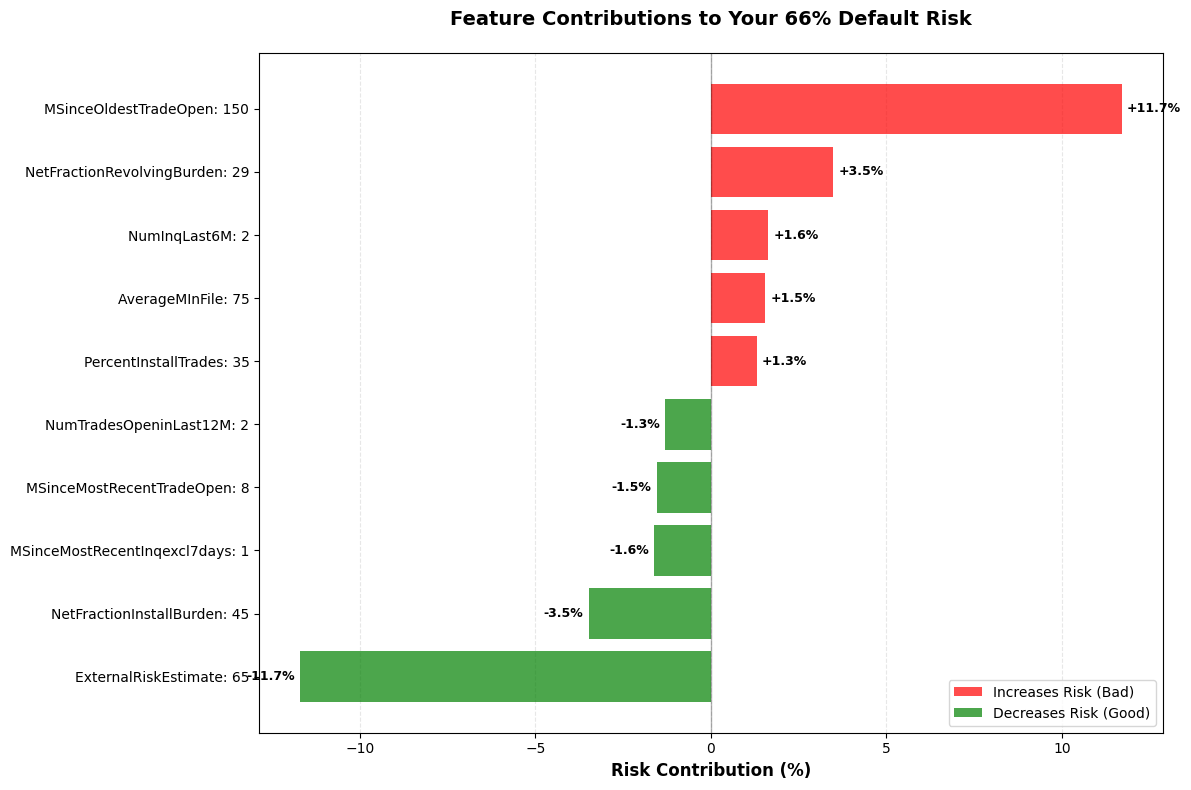

In [44]:
# Only run explanation if applicant was denied
if probability >= config['threshold']:
    
    # Compute SHAP values for this applicant
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(df_new)
    
    # Get SHAP values for Bad class
    if isinstance(shap_values, list):
        shap_values_bad = shap_values[1][0]
    else:
        shap_values_bad = shap_values[0][:22]
    
    # Ensure arrays are the same length dynamically
    shap_values_bad = np.array(shap_values_bad).flatten()
    applicant_values = np.array(df_new.iloc[0].values).flatten()
    feature_names = np.array(prep_info['feature_order'])

    # Trim or match length dynamically
    min_len = min(len(feature_names), len(applicant_values), len(shap_values_bad))
    feature_names = feature_names[:min_len]
    applicant_values = applicant_values[:min_len]
    shap_values_bad = shap_values_bad[:min_len]
    
    # Create explanation dataframe
    explanation_df = pd.DataFrame({
        'Feature': feature_names,
        'Your_Value': applicant_values,
        'SHAP_Impact': shap_values_bad
    }).sort_values('SHAP_Impact', key=abs, ascending=False)
    
    # TEXT EXPLANATION - TOP 5 FACTORS
    print(f"\nYour Default Risk: {probability:.1%}")
    print(f"Denial Threshold: {config['threshold']:.0%}")
    print(f"Decision: DENIED (risk exceeds threshold)\n")
    
    print("📋 TOP 5 REASONS FOR DENIAL:")
    print("-"*60)
    
    top_5 = explanation_df.head(5)
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        impact_pct = row['SHAP_Impact'] * 100
        if row['SHAP_Impact'] > 0:
            symbol = "🔴"
            impact_text = f"increased risk by {abs(impact_pct):.1f}%"
        else:
            symbol = "🟢"
            impact_text = f"decreased risk by {abs(impact_pct):.1f}%"
        
        print(f"{i}. {symbol} {row['Feature']}: {row['Your_Value']:.1f}")
        print(f"   → This {impact_text}")
    
    # IMPROVED VISUAL - HORIZONTAL BAR CHART
    print("\n📊 VISUAL BREAKDOWN:")
    
    # Take top 10 most impactful features
    top_10 = explanation_df.head(10).copy()
    
    # Convert to percentages
    top_10['Impact_Pct'] = top_10['SHAP_Impact'] * 100
    
    # Create labels with feature name and value
    top_10['Label'] = top_10.apply(
        lambda row: f"{row['Feature']}: {row['Your_Value']:.0f}", 
        axis=1
    )
    
    # Sort by impact for display
    top_10 = top_10.sort_values('Impact_Pct', ascending=True)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Color bars: red for positive (bad), green for negative (good)
    colors = ['red' if x > 0 else 'green' for x in top_10['Impact_Pct']]
    
    # Horizontal bar chart
    bars = ax.barh(range(len(top_10)), top_10['Impact_Pct'], color=colors, alpha=0.7)
    
    # Labels
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['Label'], fontsize=10)
    ax.set_xlabel('Risk Contribution (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Feature Contributions to Your {probability:.0%} Default Risk', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Add vertical line at 0
    ax.axvline(x=0, color='black', linewidth=1, linestyle='-', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_10['Impact_Pct'])):
        if abs(val) > 1:  # Only show label if impact > 1%
            label_x = val + (0.15 if val > 0 else -0.15)
            ax.text(label_x, i, f'{val:+.1f}%', 
                   va='center', ha='left' if val > 0 else 'right',
                   fontsize=9, fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.7, label='Increases Risk (Bad)'),
        Patch(facecolor='green', alpha=0.7, label='Decreases Risk (Good)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

else:
    print("\n✅ Application approved - no explanation needed!")